In [1]:
from utils.cub_config import Config
import torch
from torchvision import models, transforms
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        class_score = output[0, class_idx]
        class_score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * activations, dim=1).squeeze()

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()
        cam = cam.cpu().numpy()
        
        cam = cv2.resize(cam, (448, 448))
        return cam

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model_path = Config.MODEL
model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 200)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

Usando dispositivo: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
target_layer = model.layer4[-1]

gradcam = GradCAM(model, target_layer)

In [5]:
preprocess = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [12]:
test_images = [
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0037_49068.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0118_49191.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0077_49051.jpg",
    "../../data/CUB-200-2011/images/test/063.Ivory_Gull/Ivory_Gull_0099_49218.jpg",
]

Grad-CAM salvo em: ../../out\gradcam_Ivory_Gull_0037_49068.jpg


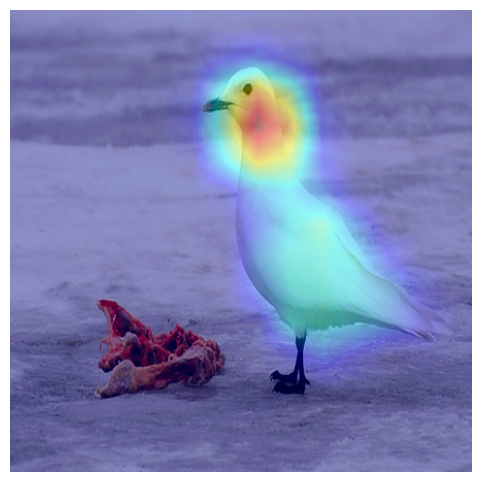

Grad-CAM salvo em: ../../out\gradcam_Ivory_Gull_0118_49191.jpg


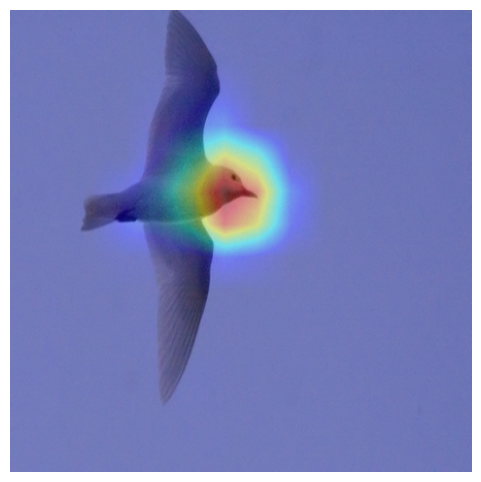

Grad-CAM salvo em: ../../out\gradcam_Ivory_Gull_0109_49382.jpg


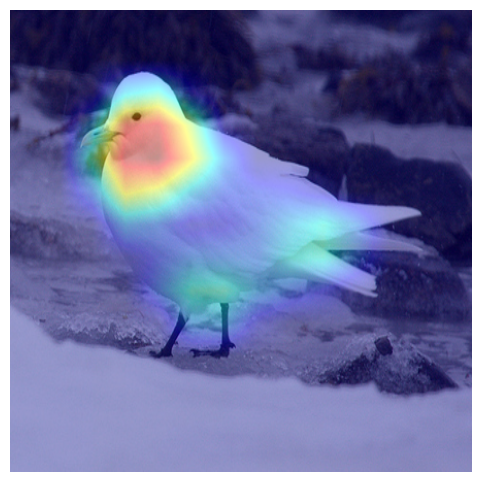

Grad-CAM salvo em: ../../out\gradcam_Ivory_Gull_0099_49218.jpg


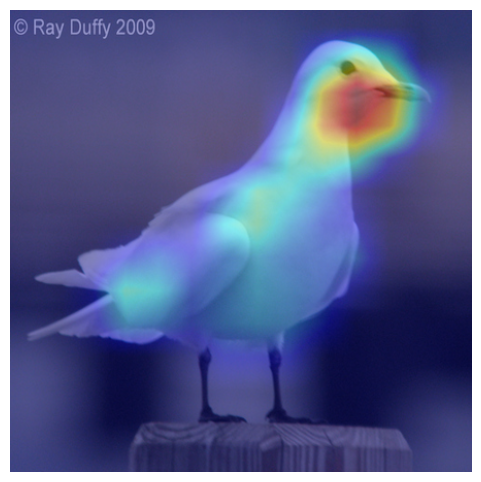

In [ ]:
for img_path in test_images:
    img_name = os.path.basename(img_path)
    raw_img = Image.open(img_path).convert("RGB")
    input_tensor = preprocess(raw_img).unsqueeze(0).to(next(model.parameters()).device)

    cam = gradcam.generate(input_tensor)

    heatmap = cv2.applyColorMap(np.uint8(255 * (1 - cam)), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    raw_np = np.array(raw_img.resize((448, 448))) / 255.0
    overlay = heatmap * 0.4 + raw_np * 0.6
    overlay = np.clip(overlay, 0, 1)

    save_path = os.path.join(Config.OUTPUT_DIR, f"gradcam_{img_name}")
    plt.imsave(save_path, overlay)
    print(f"Grad-CAM salvo em: {save_path}")

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

## AVALIAÇÃO

In [8]:
%load_ext autoreload
%autoreload 2

In [9]:
from cub_eval import deletion_test

In [7]:
test_images_26 = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0085_796839.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0035_796837.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg",
]

In [16]:
broke_list = []
for image_path in test_images:
    img = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(img).unsqueeze(0).to(next(model.parameters()).device)

    preds = model(input_tensor)
    pred_class = torch.argmax(preds, dim=1).item()
    print(f"Predicted class: {pred_class}")

    cam = gradcam.generate(input_tensor)
    heatmap = cv2.applyColorMap(np.uint8(255 * (1 - cam)), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    heatmap = np.mean(heatmap, axis=2)

    confidences, predictions, broke = deletion_test(model, input_tensor, heatmap, pred_class, max_steps=3000, pixels_per_step=200)
    print(f"Broke at step: {broke}")
    if broke is not None:
        broke_list.append(broke)


print("Broke_mean:", np.mean(broke_list))

Predicted class: 62
Broke at step: 10
Predicted class: 62
Broke at step: 29
Predicted class: 62
Broke at step: 760
Predicted class: 62
Broke at step: 570
Broke_mean: 342.25


Text(0.5, 1.0, 'Deletion Test')

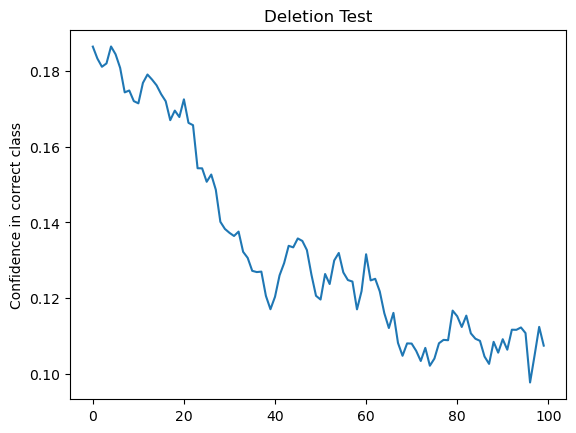

In [12]:
## plot confidences

plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')

Text(0.5, 1.0, 'Deletion Test')

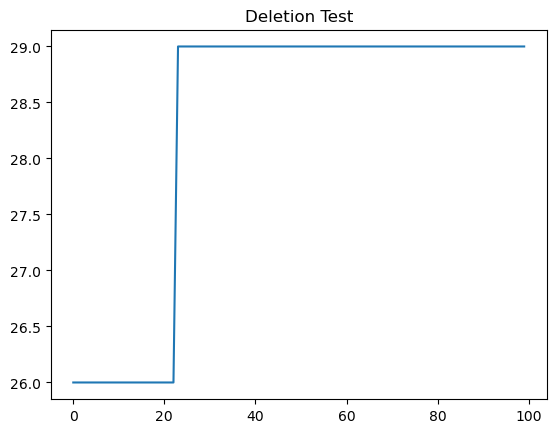

In [13]:
plt.plot(predictions)
plt.title('Deletion Test')

## ROBUSTNESS

In [17]:
from cub_eval import robustness_test

robustness_score_list = []
for image_path in test_images:
    img = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(img).unsqueeze(0).to(next(model.parameters()).device)
    robustness_score = robustness_test(model, 'GradCAM', input_tensor, gradcam.generate)
    robustness_score_list.append(robustness_score)

print("robustnesse mean:", np.mean(robustness_score_list))

robustnesse mean: 0.9866218


## SPARSITY AND SPATIAL COHERENCE

In [18]:
from cub_eval import calculate_gini_index, calculate_spatial_coherence
from skimage.measure import label

gini_list = []
coherence_list = []
for image_path in test_images:
    img = Image.open(image_path).convert('RGB')
    input_tensor = preprocess(img).unsqueeze(0).to(next(model.parameters()).device)


    cam = gradcam.generate(input_tensor)
    heatmap = cv2.applyColorMap(np.uint8(255 * (1 - cam)), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    heatmap = np.mean(heatmap, axis=2)

    gini_index = calculate_gini_index(heatmap)
    print(f"Gini Index: {gini_index}")
    gini_list.append(gini_index)

    coherence = calculate_spatial_coherence(heatmap)
    print(f"Spatial Coherence: {coherence}")
    coherence_list.append(coherence)

print("Gini mean:", np.mean(gini_list))
print("Spatial Coherence mean:", np.mean(coherence_list))

Gini Index: 0.2518763542175293
Spatial Coherence: 1.0
Gini Index: 0.16762574017047882
Spatial Coherence: 1.0
Gini Index: 0.22353370487689972
Spatial Coherence: 1.0
Gini Index: 0.26843494176864624
Spatial Coherence: 0.8673930168151855
Gini mean: 0.22786768
Spatial Coherence mean: 0.96684825


## INTRA-CLASS CONSISTENCY

In [20]:
test_images_26 = [
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0085_796839.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0035_796837.jpg",
    "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0034_796849.jpg",
]

Grad-CAM salvo em: ../../out\gradcam_Ivory_Gull_0037_49068.jpg


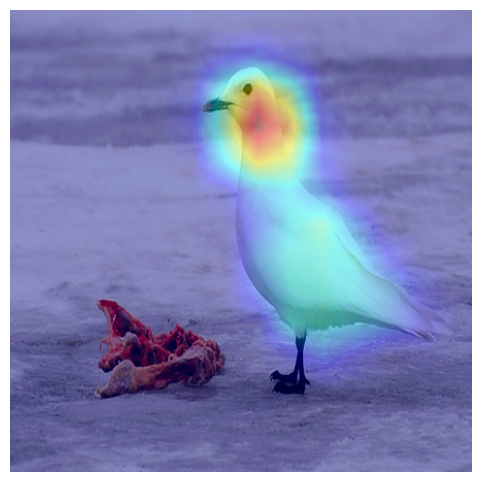

Grad-CAM salvo em: ../../out\gradcam_Ivory_Gull_0118_49191.jpg


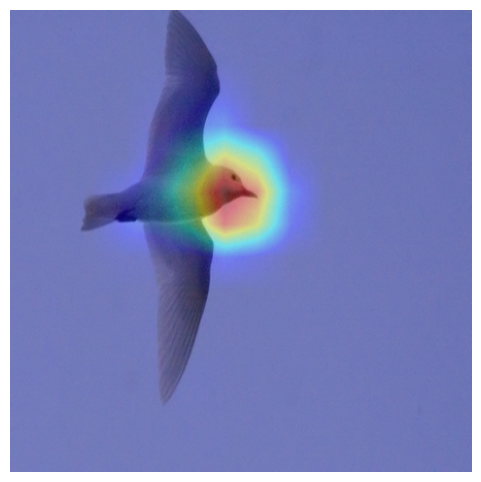

Grad-CAM salvo em: ../../out\gradcam_Ivory_Gull_0077_49051.jpg


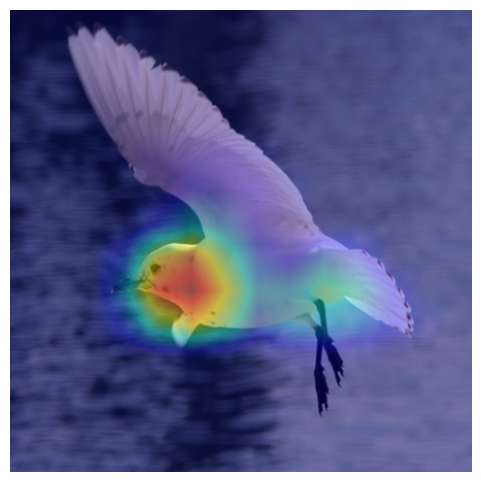

Grad-CAM salvo em: ../../out\gradcam_Ivory_Gull_0099_49218.jpg


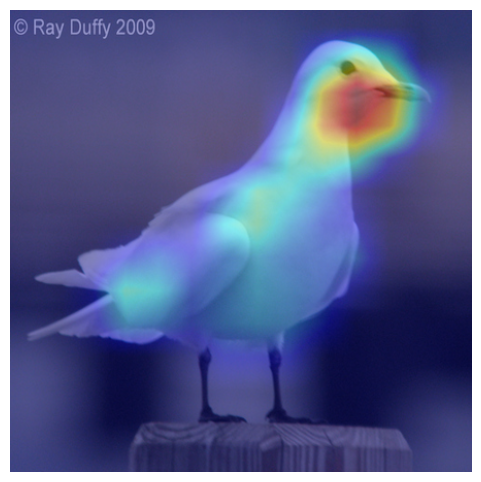

In [ ]:
heatmaps = []
for img_path in test_images:
    img_name = os.path.basename(img_path)
    raw_img = Image.open(img_path).convert("RGB")
    input_tensor = preprocess(raw_img).unsqueeze(0).to(next(model.parameters()).device)

    cam = gradcam.generate(input_tensor)

    heatmap = cv2.applyColorMap(np.uint8(255 * (1 - cam)), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    raw_np = np.array(raw_img.resize((448, 448))) / 255.0
    overlay = heatmap * 0.4 + raw_np * 0.6
    overlay = np.clip(overlay, 0, 1)

    save_path = os.path.join(Config.OUTPUT_DIR, f"gradcam_{img_name}")
    plt.imsave(save_path, overlay)
    print(f"Grad-CAM salvo em: {save_path}")

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.show()

    heatmap = heatmap.mean(axis=2)
    heatmaps.append(heatmap)

In [20]:
from cub_eval import intraclass_consistency

consistency = intraclass_consistency(heatmaps)
print(f"Intra-class Consistency: {consistency}")

Intra-class Consistency: 0.31812049732795783
